In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import os, logging, sys, torch
from tqdm import tqdm
import utils.quality_metrics as data_qm
from sklearn.preprocessing import normalize

from gretel_synthetics.timeseries_dgan.dgan import DGAN
from gretel_synthetics.timeseries_dgan.config import DGANConfig

ModuleNotFoundError: No module named 'utils'

In [7]:
# import pytables

df = pd.read_hdf('./dgan/clean_data.h5', 'df')
df

2023-12-12 14:00:15,841 : MainThread : INFO : Note: NumExpr detected 24 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
2023-12-12 14:00:15,843 : MainThread : INFO : NumExpr defaulting to 8 threads.


,Sts,x_axis,y_axis,z_axis,datetime,example_id
0,1,-0.207372,-0.188955,-0.137282,2022-09-16,0
1,1,-0.087862,-0.000164,0.028103,2022-09-16,0
2,1,-0.061989,0.003054,0.083471,2022-09-16,0
3,1,-0.041044,0.037380,-0.021513,2022-09-16,0
4,1,0.036576,-0.025908,0.051832,2022-09-16,0
...,...,...,...,...,...,...
109255,3,1.067810,0.557628,0.197802,2022-09-16,410
109256,3,1.023456,0.753929,-0.409089,2022-09-16,410
109257,3,1.062882,0.938429,-0.463019,2022-09-16,410
109258,3,0.639053,1.250578,0.806131,2022-09-16,410


In [8]:
axis_names = ['x_axis', 'y_axis', 'z_axis']
for axis in axis_names:
    print(f'{axis}: max={df[axis].max():.5f} min={df[axis].min()}')

x_axis: max=12.17483 min=-7.970578767705792
y_axis: max=8.80759 min=-10.599294881558714
z_axis: max=11.69278 min=-12.790671426752743


In [2]:
def set_gpu_device(gpu_id):
    os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
    os.environ['CUDA_VISIBLE_DEVICES'] = str(gpu_id)

def get_date_only(x):
    return str(x).split(' ')[0]

def populate_each_sampleID(df, num_repeat, groupby_colname):
    
    # Group by the specified column and convert to numpy arrays
    temp         = df.groupby(df[groupby_colname]).apply(pd.DataFrame.to_numpy)
    
    # Create a dictionary with the group keys and their corresponding data
    sampleID_dict = {key: temp[key].tolist() for key in temp.index}      
    
    # Find the maximum sequence length
    max_sequence = 0
    for key in sampleID_dict.keys():
        max_sequence = max(max_sequence, len(sampleID_dict[key]))
    
    # Data imputation
    for key in tqdm(sampleID_dict.keys(), desc="Populating_each_sample_ID…", ascii=False, ncols=75):
        n = len(sampleID_dict[key])
        repeat_times = (max_sequence - n) // num_repeat
        extra_elements = (max_sequence - n) % num_repeat

        # Append the repeated and extra elements
        sampleID_dict[key] += sampleID_dict[key][-num_repeat:] * repeat_times
        sampleID_dict[key] += sampleID_dict[key][-num_repeat: -num_repeat + extra_elements]
    
    # Compile the final list
    final_list = []
    for key in sampleID_dict.keys():
        final_list += sampleID_dict[key]
    
    final_ndarray = np.array(final_list)
    del temp, sampleID_dict, final_list #To prevent memory leak for big input DataFrame
    return pd.DataFrame(data=final_ndarray, columns=df.columns)


In [3]:
# Read GPU id from command line arguments
# gpu_id = sys.argv[1] if len(sys.argv) > 1 else '2'  # Default to '0' if no argument is provided

# Set the GPU device
gpu_id = 2
set_gpu_device(gpu_id)
print(f'GPU id {gpu_id} will be used for training.')

GPU id 2 will be used for training.


In [4]:
#===================================================================
#=============== 00. List of Globals  ==============================
#===================================================================
curr_dir = os.getcwd()
failure_type = 'Ball_Screw'
clean_data_from_scratch = 0  #Flag for concatenating all h5 files of RBCC abnormal data + Standardizing data
data_imputation         = 1  #Flag for imputing data to ensure each example_id has same sequence length 
en_save_impute_data     = 0  #Flag for saving the imputed data for quick import
read_imputed_data       = 0
train                   = 1  #Flag for training DGAN model
target_filename = 'clean_data_ballscrew.h5'
target_impute_filename = 'clean_data_ballscrew_imputed.h5'
target_filepath =  curr_dir+'/'+target_filename #If you don't have this file yet, please change variable clean_data_from_scratch to 1 and rerun this script again.
target_imputed_filepath = curr_dir+'/'+target_impute_filename

In [5]:
#===================================================================
#=============== 01. Constructing DF in Long Format ================
#===================================================================
# Globals #
cols_to_drop = ['date', 'time']
# abnormal_path_dict = {'Belt_wheel'     : '../data/AHC-A3/abnormal/Belt_wheel/Belt_wheel_220228/',
#                       'BartoBarFailure': '../data/AHC-A3/abnormal/BartoBarFailure/BartoBarFailure_20220328',
#                       'Ball_Screw'     : '../data/AHC-A3/abnormal/Ball_screw/Ball_screw_220916',
#                      } # TODO: OOM if load all the data and pad them. --> 493GBytes for array of shape (689530590, 6)
abnormal_path_dict = {'Ball_Screw'     : '../data/AHC-A3/abnormal/Ball_screw/Ball_screw_220916',
                     }

# Concatenating all abnormal data in a single DF (also called as Long Format) #
if clean_data_from_scratch:
    abnormal_files = [f for f in os.listdir(abnormal_path_dict[failure_type]) if f.endswith('.h5')]
    df = pd.DataFrame()
    for i, f in enumerate(abnormal_files):
        #if i>3: break
        full_path = os.path.join(abnormal_path_dict[failure_type], f)
        temp = pd.read_hdf(full_path, 'df')
        temp['example_id'] = i
        temp.drop(cols_to_drop, axis=1, inplace=True)
        temp['datetime'] = temp['datetime'].apply(get_date_only)
        df = pd.concat([df, temp], axis=0)
        print(f'Iteration ({i+1}/{len(abnormal_files)}) => temp: {temp.shape}, df: {df.shape}')
    print(f'df.head(5): \n{df.head(5)}')

In [6]:
#===================================================================
#=============== 02. Standardizing Data ~ N(0,1)    ================
#===================================================================

# Globals #
axis_names = ['x_axis', 'y_axis', 'z_axis']
convert_cols = ['Sts'] + axis_names
example_id_column = 'example_id'

if clean_data_from_scratch:
    df[convert_cols] = df[convert_cols].apply(pd.to_numeric, errors='coerce')
    for ax in axis_names:
        df[ax] = (df[ax]-df[ax].mean())/df[ax].std()
    print(f'x_axis: {df.x_axis.mean():.2f}, {df.x_axis.std():.2f} | y_axis: {df.y_axis.mean():.2f}, {df.y_axis.std():.2f} | z_axis: {df.z_axis.mean():.2f}, {df.z_axis.std():.2f}')
    
    try:
        print('Saving...')
        df.to_hdf(target_filename, key='df', mode='w')
    except Exception as e:
        print(f'Exception {e} has occurred.')
        
    print(f'Saving output h5 file post standardizing is complete..')

In [7]:
#===================================================================
#=== 03. Data Imputation by Replication of Last 1000 Timestamps ====
#===================================================================

if read_imputed_data:
    df = pd.read_hdf(target_imputed_filepath, 'df')
else:
    try:
        df = pd.read_hdf(target_filepath, 'df')
    except Exception as e:
        print(f'Exception {e} has occured.')
    
print(f'Reading Input DataFrame is complete...')
print(f'\n\ndf.head(5):\n{df.head(5)}\n\ndf.tail(5):\n{df.tail(5)}\n\n')


Reading Input DataFrame is complete...


df.head(5):
   Sts    x_axis    y_axis    z_axis    datetime  example_id
0    1 -0.207372 -0.188955 -0.137282  2022-09-16           0
1    1 -0.087862 -0.000164  0.028103  2022-09-16           0
2    1 -0.061989  0.003054  0.083471  2022-09-16           0
3    1 -0.041044  0.037380 -0.021513  2022-09-16           0
4    1  0.036576 -0.025908  0.051832  2022-09-16           0

df.tail(5):
        Sts    x_axis    y_axis    z_axis    datetime  example_id
109255    3  1.067810  0.557628  0.197802  2022-09-16         410
109256    3  1.023456  0.753929 -0.409089  2022-09-16         410
109257    3  1.062882  0.938429 -0.463019  2022-09-16         410
109258    3  0.639053  1.250578  0.806131  2022-09-16         410
109259    3  0.007007  1.937092  0.606231  2022-09-16         410




In [8]:
# Data type formatting is required
df['datetime'] = pd.to_datetime(df['datetime'])    
df['Sts'] = df['Sts'].astype('UInt8')
df['example_id'] = df['example_id'].astype('UInt32')
print(df.dtypes)

Sts                    UInt8
x_axis               float64
y_axis               float64
z_axis               float64
datetime      datetime64[ns]
example_id            UInt32
dtype: object


In [9]:
# Minor data cleaning for handful of unusually long data instances.
# TODO: Need to find out why are there 1 to 2 instances where the threshold length is exceeded!!!
# Count the number of sequences that exceed the threshold
threshold_length = 150000
sequence_lengths = df.groupby('example_id').apply(lambda x: len(x))
max_seq_len = df.groupby('example_id').size().max()
print('Max sequence length: ', max_seq_len)

num_long_sequences = (sequence_lengths > threshold_length).sum()
print(f"Number of sequences longer than {threshold_length}: {num_long_sequences}")

Max sequence length:  1677690
Number of sequences longer than 150000: 2


In [10]:
# Extract example IDs of long sequences and print them out
long_seqids_to_drop = sequence_lengths[sequence_lengths > threshold_length].index

# print(sequence_lengths)
# print(long_seqids_to_drop)
for seq_id in long_seqids_to_drop:
    length = sequence_lengths[seq_id]
    print(f"Sequence ID: {seq_id}, Length: {length}")

Sequence ID: 159, Length: 1677690
Sequence ID: 318, Length: 715200


In [11]:
# Drop the instances that exceed the threshold
df = df[~df['example_id'].isin(long_seqids_to_drop)]
df.reset_index(drop=True, inplace=True)   # Reset the index of the filtered DataFrame
max_seq_len = df.groupby('example_id').size().max()  # Recalculate the max sequence length, after dropping anomaly data.

In [12]:
# ----------- KO's debugging only -------------
# Before imputation
# print("Before imputation:")
# print(df.groupby(example_id_column).size().describe())

# # After imputation
# num_repeat = 1000
# df = populate_each_sampleID(df, num_repeat, example_id_column)
# print("\nAfter imputation:")
# grouped_sizes = df.groupby(example_id_column).size()
# print(grouped_sizes.describe())

# # Check if all groups have the same length
# if not grouped_sizes.nunique() == 1:
#     print("\nAnomaly detected: Not all groups have the same length.")

# # Compare with expected max_sequence_len
# expected_max_len = df.groupby('example_id').size().max() #1677690  # Replace with the actual value used in your model configuration
# if grouped_sizes.unique()[0] != expected_max_len:
#     print(f"\nMismatch detected: Expected max sequence length is {expected_max_len}, but found {grouped_sizes.unique()[0]}")


In [13]:
if clean_data_from_scratch or data_imputation:
    num_repeat = 1000

    # print('Before Data Imputation')
    # for col in df.columns.to_list():
    #     print(f'{col}: {df[col].shape}')
    
    print(f'Performing data imputation...')
    df = populate_each_sampleID(df, num_repeat, example_id_column)
    
    # Sequence length error checking
    grouped_sizes = df.groupby(example_id_column).size()
    if grouped_sizes.unique()[0] != max_seq_len:
        print(f"\nMismatch detected: Expected max sequence length is {max_seq_len}, but found {grouped_sizes.unique()[0]}")
    
    if en_save_impute_data:
        print(f'saving imputed data as {target_impute_filename}')
        df.to_hdf(target_impute_filename, key='df', mode='w')

    # print('After Data Imputation')
    # for col in df.columns.to_list():
    #     print(f'{col}: {df[col].shape}')

# ---------------- Kevin's Debugging (23-Nov-23)    

Performing data imputation...


Populating_each_sample_ID…: 100%|██████| 409/409 [00:00<00:00, 3203.13it/s]


In [14]:
# Reinstate back the original column attributes due to data imputation        
df['datetime'] = pd.to_datetime(df['datetime'])   # Format the datetime column 
df['Sts'] = df['Sts'].astype('UInt8')
df['x_axis'] = df['x_axis'].astype('float64')
df['y_axis'] = df['y_axis'].astype('float64')
df['z_axis'] = df['z_axis'].astype('float64')
df['example_id'] = df['example_id'].astype('UInt32')
print('Re-instated original data types. Check below')
print(df.dtypes)        


for column_name in df.columns:
    if df[column_name].dtype == "O":
        logging.info(
            f"Marking column {column_name} as discrete because its type is string/object."
        )

Re-instated original data types. Check below
Sts                    UInt8
x_axis               float64
y_axis               float64
z_axis               float64
datetime      datetime64[ns]
example_id            UInt32
dtype: object


In [15]:
df.head()

,Sts,x_axis,y_axis,z_axis,datetime,example_id
0,1,-0.207372,-0.188955,-0.137282,2022-09-16,0
1,1,-0.087862,-0.000164,0.028103,2022-09-16,0
2,1,-0.061989,0.003054,0.083471,2022-09-16,0
3,1,-0.041044,0.037380,-0.021513,2022-09-16,0
4,1,0.036576,-0.025908,0.051832,2022-09-16,0


In [16]:
df['Machine_type'] = 1 # 1: 'AHC-A3'
df['Machine_type'] = df['Machine_type'].astype('UInt8')

In [17]:
# load_model_fname = 'dgan/DGAN_sample_len_20percent_lr_1e04_500ep.model'
model_fname = 'dgan/DGAN_sample_len_20percent_lr_3e05_lstm256_dis_attirbdiscrim_300epoch.model'

In [18]:
# model=DGAN(DGANConfig(max_sequence_len=max_seq_len,         #Set to this value as the max number of timestamps per sample is around 100k
#                             sample_len=0.1*max_seq_len,         #It is advised in the docs to set ratio between max_sequence_len and sample_len between 10 and 20
#                             apply_feature_scaling=False,
#                             apply_example_scaling=False,
#                             use_attribute_discriminator=False,
#                             generator_learning_rate=1e-4,
#                             discriminator_learning_rate=1e-4,
#                             batch_size=115,                       #Default value is 1000; batch size 1 takes ~390MB of VRAM
#                             epochs=800))                        #For large dataset, it is appropriate to set epochs between 100 to 1000

In [19]:
if train:     
    model=DGAN(DGANConfig(max_sequence_len=max_seq_len,         #Set to this value as the max number of timestamps per sample is around 100k
                            sample_len=0.2*max_seq_len,         #It is advised in the docs to set ratio between max_sequence_len and sample_len between 10 and 20
                            apply_feature_scaling=True,        # KO: Bad results when set to
                            apply_example_scaling=False,
                            use_attribute_discriminator=False,   # KO: 30-1 6pm set to True(default), This was previously set to False.
                            attribute_num_units=256,            # Default value is 100 units per layer for GAN discriminator network
                            feature_num_units=256,              # Number of LSTM units per layer in GAN generator network
                            generator_learning_rate=3e-5,
                            discriminator_learning_rate=3e-5,
                            batch_size=48,                       #Default value is 1000; batch size 1 takes ~390MB of VRAM; if sample_len is 20%, max_batch_sz=48, elif sample_len is 10%, max_batch_sz=115
                            epochs=300))                        #For large dataset, it is appropriate to set epochs between 100 to 1000

    # 800 epochs took 1028minutes ~= 1.5minutes/epoch
    print('Training mode engaged. Training DGAN model....')
    model.train_dataframe(df,
                            attribute_columns=['Machine_type'],           #Columns that do not vary across timestamps
                            feature_columns=axis_names,          #Columns that        vary across timestamps
                            example_id_column=example_id_column, #A column that indicates the sample ID number
                            time_column="datetime",              #A column that comprises information of date only
                            discrete_columns=['Sts'],            #Columns that are of discrete in nature
                            df_style="long",                     #"long" for multi-variate time-series dataset and "wide" for univariate time-series dataset
                        )
else:
    print('Load DGAN model engaged. Loading....')
    model = DGAN.load(model_fname)  # Loading time ranges between 4 to 10 minutes.

Training mode engaged. Training DGAN model....
Number of GPUs found are 1
Device used for training is: cuda


2023-12-04 11:37:08,056 : MainThread : INFO : epoch: 0
2023-12-04 11:43:38,110 : MainThread : INFO : epoch: 1
2023-12-04 11:50:00,843 : MainThread : INFO : epoch: 2
2023-12-04 11:56:17,393 : MainThread : INFO : epoch: 3
2023-12-04 12:02:18,025 : MainThread : INFO : epoch: 4
2023-12-04 12:08:23,511 : MainThread : INFO : epoch: 5
2023-12-04 12:14:21,999 : MainThread : INFO : epoch: 6
2023-12-04 12:20:20,074 : MainThread : INFO : epoch: 7
2023-12-04 12:26:24,586 : MainThread : INFO : epoch: 8
2023-12-04 12:32:34,738 : MainThread : INFO : epoch: 9
2023-12-04 12:38:37,717 : MainThread : INFO : epoch: 10
2023-12-04 12:44:39,350 : MainThread : INFO : epoch: 11
2023-12-04 12:50:54,971 : MainThread : INFO : epoch: 12
2023-12-04 12:57:24,903 : MainThread : INFO : epoch: 13
2023-12-04 13:03:49,912 : MainThread : INFO : epoch: 14
2023-12-04 13:09:54,382 : MainThread : INFO : epoch: 15
2023-12-04 13:15:59,377 : MainThread : INFO : epoch: 16
2023-12-04 13:22:00,408 : MainThread : INFO : epoch: 17
20

In [20]:
if train:
    model.save(model_fname)
    print('DGAN model saved.')

DGAN model saved.


In [21]:
# import torch
# torch.cuda.device_count()

In [22]:
# Generate Synthetic data using DGAN model
#Add a code here to read generator network pickle from previous Section 04 so that we don't need to go through time-wasting re-training again
synthetic_df = model.generate_dataframe(400)
# print(type(synthetic_df))
    

2023-12-05 17:33:51,969 : MainThread : WARNING : The following discrete columns ({'Sts'}) were not in the generated DataFrame, you may want to ensure this is intended!


In [23]:
# synthetic_df.describe()
sensor_cols = ['x_axis', 'y_axis', 'z_axis']  # Columns to add noise to

In [24]:
# Compare the Correlation between Real and Synthetic Dataframes
# print("Correlation in real data:")
# print(df[sensor_cols].corr())
# print()
# print("Correlation in synthetic data:")
# print(synthetic_df[sensor_cols].corr())

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

# Unified histogram plotting function with statistical metrics
def plot_histograms(real_data, synthetic_data, axis_name, compare_by_sts=False):
    def add_stats_to_plot(real_data, synthetic_data, axis_name, ax):
        # Calculate statistics
        mean_real, std_real = real_data.mean(), real_data.std()
        mean_synthetic, std_synthetic = synthetic_data.mean(), synthetic_data.std()
        ks_stat, ks_p = ks_2samp(real_data, synthetic_data)

        # Display statistics on plot
        ax.text(0.02, 0.95, f'Real: mean={mean_real:.2f}, std={std_real:.2f}', transform=ax.transAxes)
        ax.text(0.02, 0.90, f'Synth: mean={mean_synthetic:.2f}, std={std_synthetic:.2f}', transform=ax.transAxes)
        ax.text(0.02, 0.85, f'K-S Test: stat={ks_stat:.2f}, p={ks_p:.2f}', transform=ax.transAxes)

    if compare_by_sts:
        sts_values = real_data['Sts'].unique()

        for sts in sts_values:
            fig, ax = plt.subplots(figsize=(10, 4))

            # Filter data by 'Sts' value
            filtered_real_data = real_data[real_data['Sts'] == sts][axis_name]
            filtered_synthetic_data = synthetic_data[synthetic_data['Sts'] == sts][axis_name]

            ax.hist(filtered_real_data, bins=30, alpha=0.5, label=f'Real Data (Sts={sts})')
            ax.hist(filtered_synthetic_data, bins=30, alpha=0.5, label=f'Synthetic Data (Sts={sts})')

            add_stats_to_plot(filtered_real_data, filtered_synthetic_data, axis_name, ax)

            ax.set_xlabel(f'{axis_name} Value')
            ax.set_ylabel('Frequency')
            ax.set_title(f'Comparison on {axis_name} Axis (Sts={sts})')
            ax.legend()

            plt.show()
    else:
        fig, ax = plt.subplots(figsize=(10, 4))

        ax.hist(real_data[axis_name], bins=30, alpha=0.5, label='Real Data')
        ax.hist(synthetic_data[axis_name], bins=30, alpha=0.5, label='Synthetic Data')

        add_stats_to_plot(real_data[axis_name], synthetic_data[axis_name], axis_name, ax)

        ax.set_xlabel(f'{axis_name} Value')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Comparison on {axis_name} Axis')
        ax.legend()

        plt.show()

# Function to add Gaussian noise to a DataFrame
def add_gaussian_noise(df, std_dev, columns):
    # Copy the DataFrame to avoid modifying the original
    df_noisy = df.copy()
    
    # Add Gaussian noise to each specified column
    for col in columns:
        noise = np.random.normal(0, std_dev, df_noisy[col].shape)
        df_noisy[col] += noise
    
    return df_noisy

# Unified histogram plotting function with statistical metrics
def plot_combined_histograms(real_data, synthetic_data, axis_names, compare_by_sts=False):
    def add_stats_to_plot(real_data, synthetic_data, axis_name, ax):
        # Calculate statistics
        mean_real, std_real = real_data.mean(), real_data.std()
        mean_synthetic, std_synthetic = synthetic_data.mean(), synthetic_data.std()
        ks_stat, ks_p = ks_2samp(real_data, synthetic_data)

        # Display statistics on plot
        ax.text(0.02, 0.95, f'Real: mean={mean_real:.2f}, std={std_real:.2f}', transform=ax.transAxes)
        ax.text(0.02, 0.90, f'Synth: mean={mean_synthetic:.2f}, std={std_synthetic:.2f}', transform=ax.transAxes)
        ax.text(0.02, 0.85, f'K-S Test: stat={ks_stat:.2f}, p={ks_p:.2f}', transform=ax.transAxes)

    num_axes = len(axis_names)
    fig, axes = plt.subplots(num_axes, 1, figsize=(10, 4 * num_axes))

    if compare_by_sts:
        sts_values = real_data['Sts'].unique()
        for sts in sts_values:
            for i, axis_name in enumerate(axis_names):
                # Filter data by 'Sts' value
                filtered_real_data = real_data[real_data['Sts'] == sts][axis_name]
                filtered_synthetic_data = synthetic_data[synthetic_data['Sts'] == sts][axis_name]

                ax = axes[i]
                ax.hist(filtered_real_data, bins=30, alpha=0.5, label=f'Real Data (Sts={sts})')
                ax.hist(filtered_synthetic_data, bins=30, alpha=0.5, label=f'Synthetic Data (Sts={sts})')

                add_stats_to_plot(filtered_real_data, filtered_synthetic_data, axis_name, ax)

                ax.set_xlabel(f'{axis_name} Value')
                ax.set_ylabel('Frequency')
                ax.set_title(f'Comparison on {axis_name} Axis (Sts={sts})')
                ax.legend()
    else:
        for i, axis_name in enumerate(axis_names):
            ax = axes[i]
            ax.hist(real_data[axis_name], bins=30, alpha=0.5, label='Real Data')
            ax.hist(synthetic_data[axis_name], bins=30, alpha=0.5, label='Synthetic Data')

            add_stats_to_plot(real_data[axis_name], synthetic_data[axis_name], axis_name, ax)

            ax.set_xlabel(f'{axis_name} Value')
            ax.set_ylabel('Frequency')
            ax.set_title(f'Comparison on {axis_name} Axis')
            ax.legend()

    plt.tight_layout()
    plt.show()

def plot_distributions(real_data, synthetic_data, save_dir='plots', plot_title='Real vs Synthetic', fname='vibration_distribution_comparison'):
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 8))
    
    for i, axis in enumerate(['x_axis', 'y_axis', 'z_axis']):
        sns.kdeplot(real_data[axis], ax=axes[i], fill=True, label='Real Data')
        sns.kdeplot(synthetic_data[axis], ax=axes[i], fill=True, label='Synthetic Data')
        axes[i].set_title(f'{plot_title} Distribution for Vibration {axis}')
        axes[i].legend()

    plt.tight_layout()
    
    # Save figures to the plots directory
    # plt.savefig(f'{save_dir}/{fname}.png')
    plt.show()

def extended_plot_distributions(real_df, synthetic_df, gauss_df, save_dir='plots', plot_title='Real vs Synthetic vs Gaussian', fname='vibration_distribution_comparison'):
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 9))

    for i, axis in enumerate(['x_axis', 'y_axis', 'z_axis']):
        # Real vs Synthetic
        sns.kdeplot(real_df[axis], ax=axes[i, 0], color='blue', fill=True, label='Real Data')
        sns.kdeplot(synthetic_df[axis], ax=axes[i, 0], color='green', fill=True, label='Synthetic Data')
        axes[i, 0].set_title(f'{plot_title} Distribution for {axis} (Real vs Synthetic)')
        axes[i, 0].legend()

        # Real vs Gaussian
        sns.kdeplot(real_df[axis], ax=axes[i, 1], color='blue', fill=True, label='Real Data')
        sns.kdeplot(gauss_df[axis], ax=axes[i, 1], color='red', fill=True, label='Gaussian Data')
        axes[i, 1].set_title(f'{plot_title} Distribution for {axis} (Real vs Gaussian)')
        axes[i, 1].legend()

    plt.tight_layout()
    
    # Save figures to the specified directory
    # plt.savefig(f'{save_dir}/{fname}.png')
    plt.show()

# def plot_side_by_side_distributions(real_data, synthetic_data, gaussian_data, save_dir='plots', plot_title='Distribution Comparison', fname='vibration_distribution_comparison'):
#     if not os.path.exists(save_dir):
#         os.makedirs(save_dir)

#     fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))  # Adjust for 3 columns for real, synthetic, and gaussian data
    
#     for i, axis in enumerate(['x_axis', 'y_axis', 'z_axis']):
#         # Real Data
#         sns.kdeplot(real_data[axis], ax=axes[i][0], fill=True, label='Real Data', color='blue')
#         axes[i][0].set_title(f'Real Data {axis}')
#         axes[i][0].legend()

#         # Synthetic Data
#         sns.kdeplot(synthetic_data[axis], ax=axes[i][1], fill=True, label='Synthetic Data', color='green')
#         axes[i][1].set_title(f'Synthetic Data {axis}')
#         axes[i][1].legend()

#         # Gaussian Data
#         sns.kdeplot(gaussian_data[axis], ax=axes[i][2], fill=True, label='Gaussian Data', color='red')
#         axes[i][2].set_title(f'Gaussian Data {axis}')
#         axes[i][2].legend()

#     plt.tight_layout()
    
#     # Save figures to the plots directory
#     plt.savefig(f'{save_dir}/{fname}.png')
#     plt.show()


In [26]:
# Create gaussian noise-based dataset as controlled sample.
std_dev = 0.3  # User-specified standard deviation for the Gaussian noise

gauss_df = add_gaussian_noise(df, std_dev, sensor_cols)

# Example of how to use plot_histograms to compare the original and noisy data
# Assuming 'real_df' is your original dataframe and 'gauss_df' is the noisy one
# plot_histograms(df, gauss_df, 'x_axis', compare_by_sts=False)
# plot_histograms(df, gauss_df, 'y_axis', compare_by_sts=False)
# plot_histograms(df, gauss_df, 'z_axis', compare_by_sts=False)


In [27]:
# Plot histogram comparing individual vibration axis data
# Normal histogram comparison
# plot_histograms(df, synthetic_df, 'x_axis', compare_by_sts=False)
# plot_histograms(df, synthetic_df, 'y_axis', compare_by_sts=False)
# plot_histograms(df, synthetic_df, 'z_axis', compare_by_sts=False)

In [28]:
# Combine all plots into single graph 
# plot_combined_histograms(df, synthetic_df, ['x_axis', 'y_axis', 'z_axis'])

In [29]:
# plot_combined_histograms(gauss_df, synthetic_df, ['x_axis', 'y_axis', 'z_axis'])

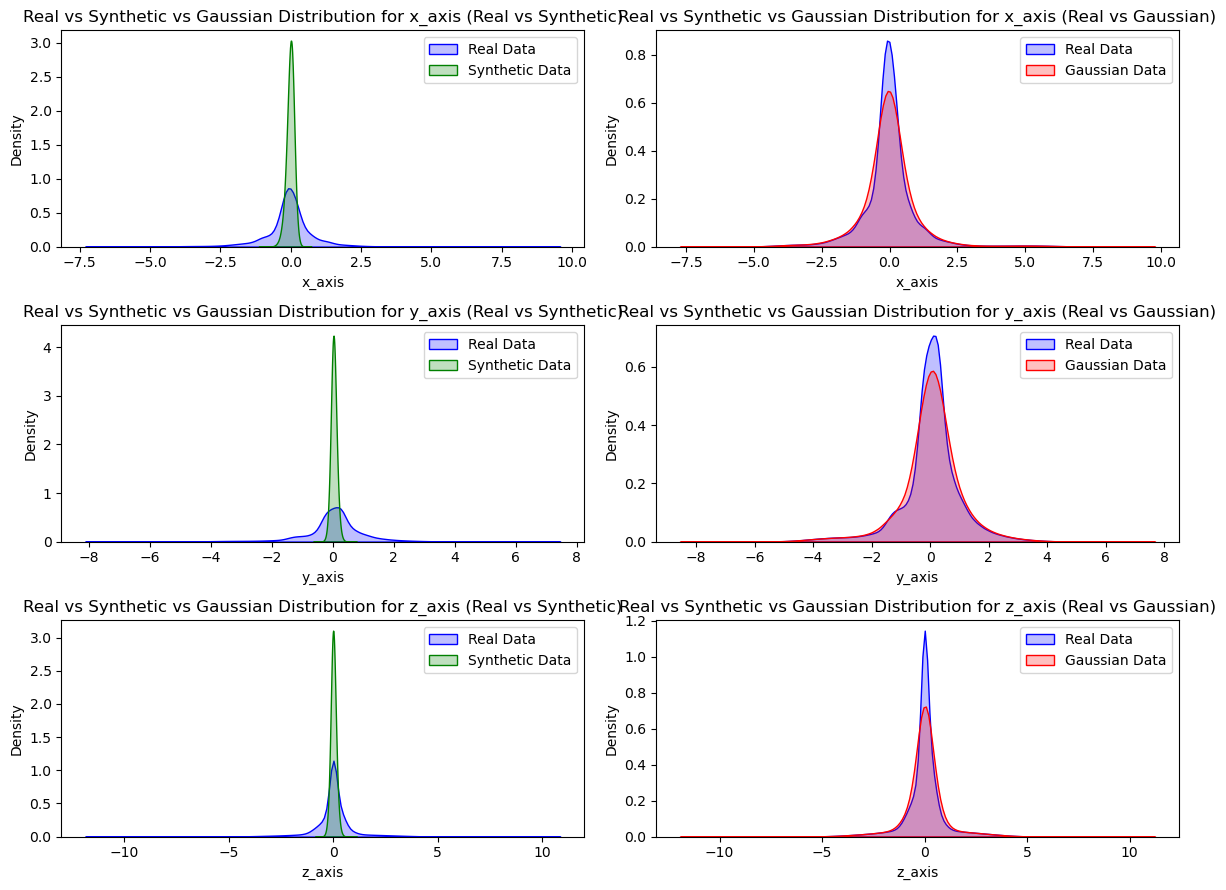

In [30]:
# KDE Plots for comparison.
# plot_distributions(df, synthetic_df, fname='real_vs_synthetic_vib_compare') # Real vs Synthetic KDE plot
# plot_distributions(df, gauss_df, fname='real_vs_noisy_vib_compare') # Real vs Noisy KDE plot

tmp_disable = False
if (tmp_disable == False):
    extended_plot_distributions(df, synthetic_df, gauss_df) # May take around 40minutes to plot the full dataframe

In [31]:
# Modifying the code for side-by-side visual comparisons
from sklearn.manifold import TSNE
from scipy.spatial.distance import pdist, squareform
from scipy.fft import fft

def side_by_side_comparison(real_df, synthetic_df, gauss_df, comparison_function, title, percentage=0.5): #, n_samples=500):
    sensor_cols = ['x_axis', 'y_axis', 'z_axis']    
    
    n_samples = int(percentage*len(df))  # Use 40% of the datasets for analysis.
    real_df_sample = real_df[sensor_cols].head(n_samples)
    synthetic_df_sample = synthetic_df[sensor_cols].head(n_samples)
    gauss_df_sample = gauss_df[sensor_cols].head(n_samples)
    
    num_sensors = len(sensor_cols)
    fig, axes = plt.subplots(num_sensors, 3, figsize=(15, 5 * num_sensors))

    for i, sensor in enumerate(sensor_cols):
        # Real Data
        ax = plt.subplot(num_sensors, 3, i * 3 + 1)
        if comparison_function == plot_pairwise_distances:
            comparison_function(real_df_sample[[sensor]])
        else:
            comparison_function(real_df_sample[[sensor]], 'blue', 'Real Data')
        plt.title(f'Real Data ({sensor}) - {title}')

        # Synthetic Data
        ax = plt.subplot(num_sensors, 3, i * 3 + 2)
        if comparison_function == plot_pairwise_distances:
            comparison_function(synthetic_df_sample[[sensor]])
        else:
            comparison_function(synthetic_df_sample[[sensor]], 'green', 'Synthetic Data')
        plt.title(f'Synthetic Data ({sensor}) - {title}')

        # Gaussian Data
        ax = plt.subplot(num_sensors, 3, i * 3 + 3)
        if comparison_function == plot_pairwise_distances:
            comparison_function(gauss_df_sample[[sensor]])
        else:
            comparison_function(gauss_df_sample[[sensor]], 'red', 'Gaussian Data')
        plt.title(f'Gaussian Data ({sensor}) - {title}')

    plt.tight_layout()
    plt.show()

# Function to plot pairwise distances for side-by-side comparison
def plot_pairwise_distances(df):
    distances = pdist(df, metric='euclidean')
    square_distances = squareform(distances)
    plt.imshow(square_distances, cmap='hot', interpolation='nearest')
    plt.colorbar()

# Function for t-SNE visualization for side-by-side comparison
def tsne_visualization(df, color, label):
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(df)
    plt.scatter(tsne_results[:, 0], tsne_results[:, 1], color=color, label=label)
    plt.legend()

# Function for FFT visualization for side-by-side comparison
def fft_visualization(df, color, label):
    column_data = df.iloc[:, 0].values  # FFT for the single column passed

    # Apply FFT to the NumPy array
    fft_values = fft(column_data)
    n = len(fft_values)
    freq = np.fft.fftfreq(n, d=1)  # Adjust 'd' as per your time interval

    # Only take the first half of frequencies, as FFT output is symmetrical
    freq = freq[:n // 2]
    fft_values = fft_values[:n // 2]

    plt.plot(freq, np.abs(fft_values), color=color, label=label)
    plt.xlabel('Frequency')
    plt.ylabel('Amplitude')
    plt.legend()
    # plt.title("FFT Visualization")


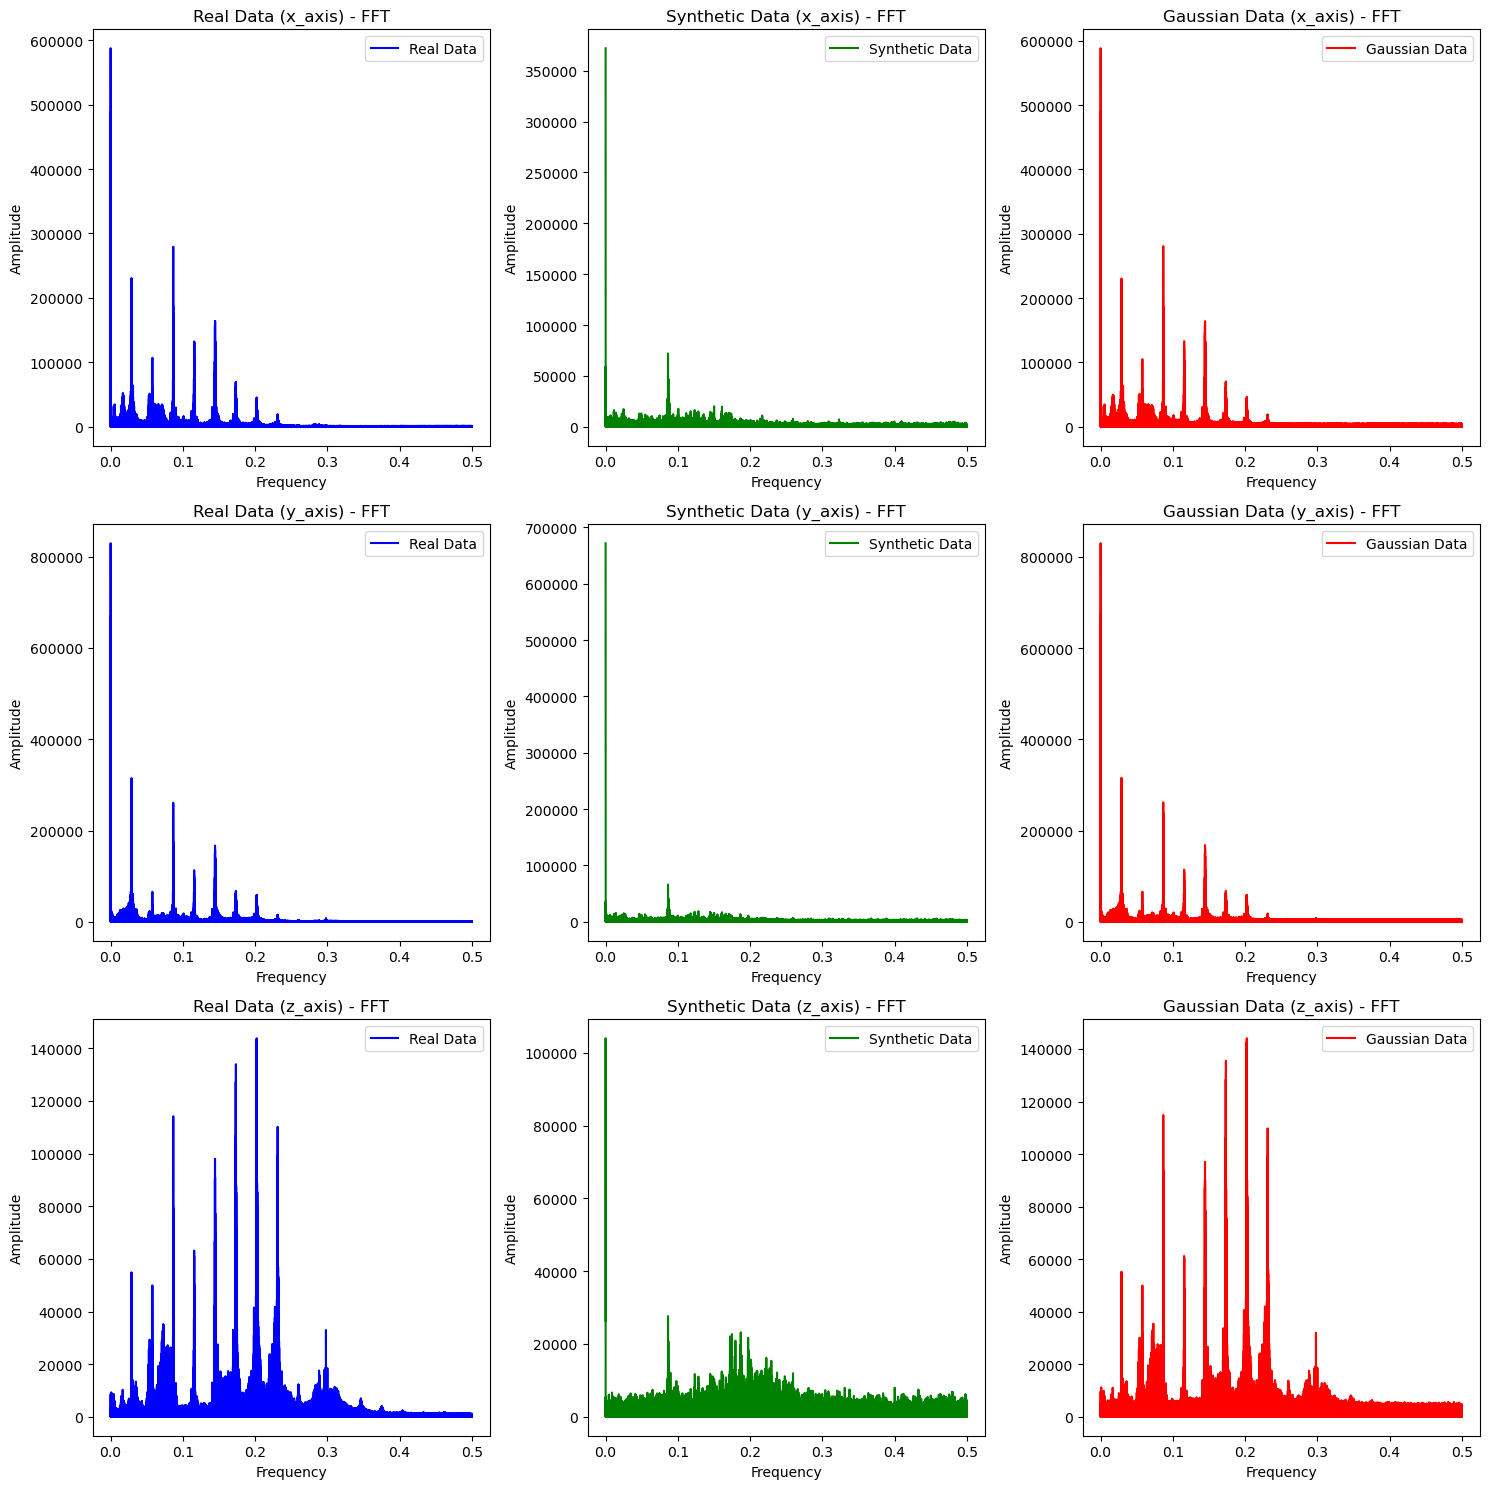

In [32]:
# Sample usage for side-by-side comparison
# Uncomment and replace 'real_df', 'synthetic_df', and 'gauss_df' with your actual anomaly dataframes
if (tmp_disable == False):
    side_by_side_comparison(df, synthetic_df, gauss_df, fft_visualization, "FFT") #, n_samples=max_seq_len)

In [33]:
# side_by_side_comparison(df, synthetic_df, gauss_df, plot_pairwise_distances, "Pairwise Distances", percentage=0.1)  # Takes 
# side_by_side_comparison(df, synthetic_df, gauss_df, tsne_visualization, "t-SNE") # Need to find GPU implementation to speed up.

In [34]:
print(df[sensor_cols].shape)
print(synthetic_df[sensor_cols].shape)

(48478770, 3)
(47412000, 3)


In [35]:
# Add the project directory in order to resolve python module path issues due to jupyter notebook
# project_dir = os.path.dirname(os.getcwd())
# sys.path.insert(0, project_dir)

In [36]:

# data_qm.check_input_shape(df[sensor_cols], synthetic_df[sensor_cols])
metrics = data_qm.evaluate_synthetic_data_multivariate(df[sensor_cols], synthetic_df[sensor_cols], sensor_cols, max_seq_len)

data_qm.print_metrics(metrics, sensor_cols) 
# data_qm.compute_wasserstein_distance(df[sensor_cols], synthetic_df[sensor_cols])

------- Feature x_axis -----------
Wasserstein Distance Feature x_axis: 0.507
KS Test Statistic Feature x_axis: 0.269
Real Data Spearman Autocorrelation Feature x_axis: 0.767
Synthetic Data Spearman Autocorrelation Feature x_axis: 0.522
Cramér-von Mises Statistic Feature x_axis: 785568.188

------- Feature y_axis -----------
Wasserstein Distance Feature y_axis: 0.592
KS Test Statistic Feature y_axis: 0.363
Real Data Spearman Autocorrelation Feature y_axis: 0.739
Synthetic Data Spearman Autocorrelation Feature y_axis: 0.194
Cramér-von Mises Statistic Feature y_axis: 1209992.127

------- Feature z_axis -----------
Wasserstein Distance Feature z_axis: 0.468
KS Test Statistic Feature z_axis: 0.233
Real Data Spearman Autocorrelation Feature z_axis: 0.323
Synthetic Data Spearman Autocorrelation Feature z_axis: 0.104
Cramér-von Mises Statistic Feature z_axis: 595003.062



In [ ]:
df = pd.read_hdf(target_h5_impt_filepath, 'df').reset_index(drop=True)


In [ ]:
import utils.utility as assistant
assistant.plot_side_by_side_plotly(df[sensor_cols], synthetic_df[sensor_cols])


In [ ]:
import random
from gretel_synthetics.timeseries_dgan.dgan import DGAN
from gretel_synthetics.timeseries_dgan.config import DGANConfig, DfStyle
import numpy as np
import pandas as pd

# Define the parameter space for tuning
param_space = {
    'generator_learning_rate': [0.001, 0.0005, 0.0001],
    'discriminator_learning_rate': [0.001, 0.0005, 0.0001],
    'batch_size': [32, 64, 100],
    'attribute_num_units': [64, 128, 256, 300],
    'feature_num_units': [64, 128, 256, 300],
    # Add more parameters as needed
}

# Function to create a DGAN model with given hyperparameters
def create_model(params):
    config = DGANConfig(
        max_sequence_len=20,  # Example value, adjust as needed
        sample_len=5,  # Example value
        generator_learning_rate=params['generator_learning_rate'],
        discriminator_learning_rate=params['discriminator_learning_rate'],
        batch_size=params['batch_size'],
        attribute_num_units=params['attribute_num_units'],
        # Set other config parameters
    )
    model = DGAN(config)
    return model

def compute_diversity(dataframe):
    """
    Compute the diversity of the generated data.

    Args:
    dataframe (pd.DataFrame): The dataframe containing generated data.

    Returns:
    float: A diversity score.
    """
    # Example implementation: Standard deviation of each feature
    diversity_scores = dataframe.std()
    
    # Aggregate the scores - many strategies could be used here
    overall_diversity = np.mean(diversity_scores)

    return overall_diversity


# Function to evaluate the model (e.g., diversity of generated samples)
def evaluate_model(model, real_df):
    # Generate synthetic data and compare with real data
    synthetic_data = model.generate_dataframe(len(real_df))
    # Implement diversity and quality metrics
    diversity_score = compute_diversity(synthetic_data)
    return diversity_score

def determine_threshold(real_df):
    """
    Determine a threshold for diversity based on the real data.

    Args:
    real_df (pd.DataFrame): The dataframe containing real data.

    Returns:
    float: A threshold value for diversity.
    """
    real_diversity = compute_diversity(real_df)
    threshold = 0.8 * real_diversity  # Example: 80% of real data diversity
    return threshold

# Usage
diversity_threshold = determine_threshold(df)

# Hyperparameter tuning loop
best_score = float('-inf')
best_params = None

for _ in range(10):  # Number of iterations, adjust as needed
    # Randomly select hyperparameters
    params = {k: random.choice(v) for k, v in param_space.items()}
    
    # Create and train the model
    model = create_model(params)
    model.train_dataframe(df, df_style=DfStyle.LONG)

    # Evaluate the model
    score = evaluate_model(model, df)
    
    # Update best model
    if score > best_score:
        best_score = score
        best_params = params

def train_one_epoch(model, df, df_style, progress_callback=None):
    """
    Train the model for one epoch.

    Args:
    model: The DGAN model instance.
    df: DataFrame containing the training data.
    df_style: Style of the DataFrame (wide or long).
    progress_callback: Optional callback function for progress updates.
    """
    # Train the model using the provided DataFrame
    model.train_dataframe(df, df_style=df_style, progress_callback=progress_callback)

# Monitoring for mode collapse and training performance
def monitor_training(model):
    # Track and plot discriminator and generator loss
    # Check for diversity in generated samples
    # Visualize samples at regular intervals
    
    # Example: Check diversity
    diversity = evaluate_model(model, df)
    if diversity < diversity_threshold:  # Define a suitable threshold
        print("Warning: Potential mode collapse detected")

# After finding the best parameters
best_model = create_model(best_params)
# Implement your training loop here and call monitor_training at intervals

num_epochs = 100  # Set the number of epochs

# Example training loop with monitoring
for epoch in range(num_epochs):  # Define num_epochs
    
    # Train for one epoch
    train_one_epoch(best_model, df)

    # Monitor training
    monitor_training(best_model)

print('Training completed.')

In [ ]:

# shapiro-wilk test, normal test using scipy.

In [50]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.fft import fft


def get_prominent_fft_freq(df, title, sample_pct=.5, top_components=8, feature_cols=['x_axis', 'y_axis', 'z_axis']):
    print(f'\n=================== START : {title} ================\n')
    
    n_samples = int(sample_pct*len(df))
    df_sample = df[feature_cols].head(n_samples)

    ans = []
    threshold = 1.5e-2
    for col in tqdm(feature_cols, desc=f"get_prominent_fft_freq...", ascii=False, ncols=75):
        temp = []
        
        col_data   = df_sample[col].values
        fft_values = fft(col_data)
        print('Finished computing fft_values...')
        n          = len(fft_values)
        freq       = np.fft.fftfreq(n, d=1)

        fft_values = fft_values[:n//2]
        freq       = freq[:n//2]

        temp       = [[f'{np.abs(fft_values[i]):.4f}', f'{freq[i]:.4e}'] for i in range(len(fft_values))]
        temp       = sorted(temp,key=lambda l:float(l[0]), reverse=True)
        print('Finished sorting...')
        temp1      = []
        for val in temp:
            if len(temp1)==0: temp1 += [val]
            do_append = True
            for element in temp1:
                if np.abs(float(val[1])-float(element[1]))<threshold:
                    do_append = False
                    break
            if do_append: temp1 += [val]
            if len(temp1)>int(1.5*top_components): break
        ans.append(temp1)

        print(f'\n\t{col}:\n')
        for i, val in enumerate(temp1):
            if i==0: continue
            print(val)
            if i>top_components+1: break

    print(f'\n=================== FINISH: {title} ================\n')
    
    return ans



cwd_path = '/home/mluser_intern/Desktop/rbcc_git/dgan/'
real_df_path = cwd_path + 'clean_imputed_data.h5'

##Exp 3
#synt_df_path = cwd_path + '_SL1317_BS32_E1500_ANL8_ANU256_FNL8_FNU256_GLR1.0e-04_DLR1.0e-04_ADLR1.0e-04_synt_data.h5' 

##Exp 6
#synt_df_path = cwd_path + '_SL1317_BS32_E7500_ANL8_ANU256_FNL8_FNU256_GLR1.0e-04_DLR1.0e-04_ADLR1.0e-04_synt_data.h5'  

##Exp 7
#synt_df_path = cwd_path + '_SL2634_BS32_E3800_ANL16_ANU320_FNL16_FNU320_GLR1.0e-04_DLR1.0e-04_ADLR1.0e-04_synt_data.h5'

## Exp 9
#synt_df_path = cwd_path + '_SL2634_BS20_E7500_ANL8_ANU512_FNL8_FNU512_GLR1.0e-04_DLR1.0e-04_ADLR1.0e-04_synt_data.h5'

##Exp 11a
#synt_df_path = cwd_path + 'Exp11a__SL1317_BS32_E1500_ANL8_ANU256_FNL8_FNU256_GLR1.0e-04_DLR1.0e-04_ADLR1.0e-04_synt_data.h5'

##Exp 8
#synt_df_path = cwd_path + '_SL2634_BS16_E10000_ANL20_ANU512_FNL16_FNU512_GLR5.0e-05_DLR5.0e-05_ADLR5.0e-05_synt_data.h5'

##Exp 11b
#synt_df_path = cwd_path + 'Exp11b__SL1317_BS32_E1500_ANL8_ANU256_FNL8_FNU256_GLR1.0e-04_DLR1.0e-04_ADLR1.0e-04_synt_data.h5'

##Exp 11c
#synt_df_path = cwd_path + 'Exp11c__SL1317_BS32_E1500_ANL8_ANU256_FNL8_FNU256_GLR1.0e-04_DLR1.0e-04_ADLR1.0e-04_synt_data.h5'

##Exp 12
#synt_df_path = cwd_path + 'Exp12__SL1317_BS32_E1500_ANL8_ANU256_FNL8_FNU256_GLR1.0e-04_DLR1.0e-04_ADLR1.0e-04_synt_data.h5'

##Exp13
#synt_df_path = cwd_path + 'Exp13__SL2634_BS18_E1500_ANL16_ANU512_FNL16_FNU512_GLR1.0e-04_DLR1.0e-04_ADLR1.0e-04_synt_data.h5'

##Exp14
synt_df_path = cwd_path + 'Exp14__SL2634_BS18_E1500_ANL16_ANU512_FNL16_FNU512_GLR1.0e-04_DLR1.0e-04_ADLR1.0e-04_synt_data.h5'

os.chdir(cwd_path)

real_df = pd.read_hdf(real_df_path, 'df')
synt_df = pd.read_hdf(synt_df_path, 'df')

# real_df_freq = get_prominent_fft_freq(real_df, 'real_df')
# synt_df_freq = get_prominent_fft_freq(synt_df, 'synt_df')    



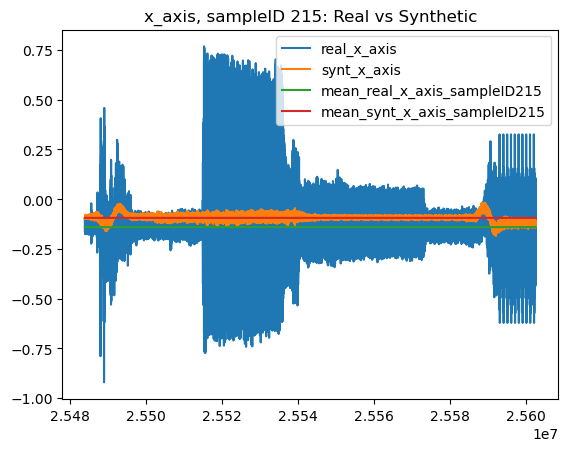

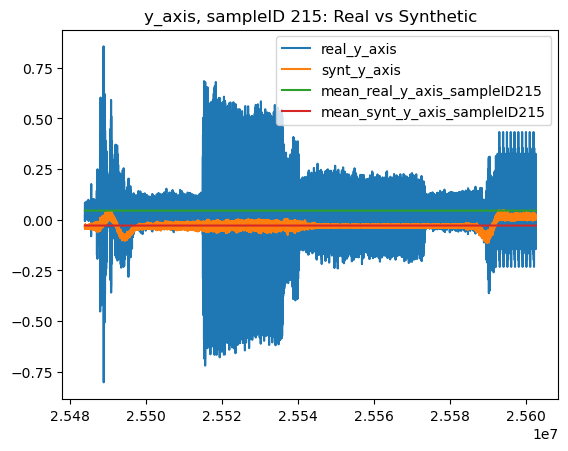

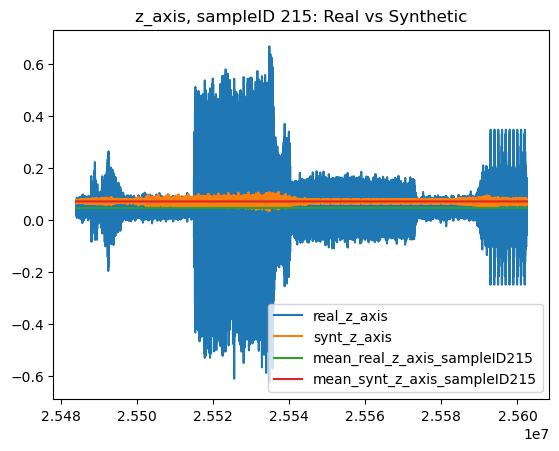

In [51]:
feature_cols = ['x_axis', 'y_axis', 'z_axis']
sampleID = 215

for col in feature_cols:
    x_df = pd.DataFrame()
    x_df['real_'+col] = real_df[real_df.example_id==sampleID][col]
    x_df['synt_'+col] = synt_df[real_df.example_id==sampleID][col]
    x_df['mean_real_'+col+'_sampleID'+str(sampleID)] = real_df[real_df.example_id==sampleID][col].mean()
    x_df['mean_synt_'+col+'_sampleID'+str(sampleID)] = synt_df[real_df.example_id==sampleID][col].mean()
    x_df.plot(title=f'{col}, sampleID {str(sampleID)}: Real vs Synthetic')

In [43]:
from scipy.fft import fft

fft_values = fft([1,2,3,4,5,6,6,3,2,1,4,1,2,4,5,3])
fft_values

array([52.        -0.j        , -1.1076506 -8.00208109j,
       -8.24264069+9.65685425j, -0.12698254+3.98953763j,
       -8.        -2.j        ,  0.95540966-2.01046237j,
        0.24264069+1.65685425j, -3.72077653-2.00208109j,
        4.        -0.j        , -3.72077653+2.00208109j,
        0.24264069-1.65685425j,  0.95540966+2.01046237j,
       -8.        +2.j        , -0.12698254-3.98953763j,
       -8.24264069-9.65685425j, -1.1076506 +8.00208109j])

In [47]:
a = torch.Tensor([1, 2, 3])
a+np.array([3, 2, 1])

tensor([4., 4., 4.], dtype=torch.float64)